In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Add, Multiply, Softmax
from tensorflow.keras.models import Model

In [19]:
df = pd.read_csv(r"D:\Datasets\BEED_Data.csv")

X = df.drop("y", axis=1).values
y = df["y"].values

print("Dataset shape:", X.shape)

Dataset shape: (8000, 16)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
def attention_block(x):

    score = Dense(x.shape[-1], activation="tanh")(x)

    weights = Softmax(axis=1)(score)

    context = Multiply()([x, weights])

    return context

In [23]:
def residual_block(x, units):

    shortcut = x

    x = Dense(units, activation="relu")(x)
    x = BatchNormalization()(x)

    x = Dense(units, activation="relu")(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])

    return x

In [24]:
def build_model(input_dim, num_classes):

    inputs = Input(shape=(input_dim,))

    x = Dense(128, activation="relu")(inputs)
    x = BatchNormalization()(x)

    x = attention_block(x)

    x = residual_block(x, 128)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation="relu")(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    return model

In [25]:
num_classes = len(np.unique(y))

model = build_model(X_train.shape[1], num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 16)]         0           []                               
                                                                                                  
 dense (Dense)                  (None, 128)          2176        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 128)         512         ['dense[0][0]']                  
 alization)                                                                                       
                                                                                                  
 dense_1 (Dense)                (None, 128)          16512       ['batch_normalization[0][0]']

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/200
160/160 [==============================] - 3s 8ms/step - loss: 0.8914 - accuracy: 0.6070 - val_loss: 1.3996 - val_accuracy: 0.2406
Epoch 2/200
160/160 [==============================] - 1s 7ms/step - loss: 0.6180 - accuracy: 0.7311 - val_loss: 1.3085 - val_accuracy: 0.5086
Epoch 3/200
160/160 [==============================] - 1s 8ms/step - loss: 0.5258 - accuracy: 0.7834 - val_loss: 0.8376 - val_accuracy: 0.6773
Epoch 4/200
160/160 [==============================] - 1s 7ms/step - loss: 0.4562 - accuracy: 0.8074 - val_loss: 0.4359 - val_accuracy: 0.8594
Epoch 5/200
160/160 [==============================] - 1s 7ms/step - loss: 0.4071 - accuracy: 0.8344 - val_loss: 0.3858 - val_accuracy: 0.8352
Epoch 6/200
160/160 [==============================] - 1s 7ms/step - loss: 0.3776 - accuracy: 0.8453 - val_loss: 0.5906 - val_accuracy: 0.7539
Epoch 7/200
160/160 [==============================] - 1s 7ms/step - loss: 0.3556 - accuracy: 0.8582 - val_loss: 0.3607 - val_accuracy: 0.8313

In [28]:
pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

dl_accuracy = accuracy_score(y_test, pred)

print("Deep Learning Accuracy:", dl_accuracy)

50/50 [==============================] - 0s 3ms/step
Deep Learning Accuracy: 0.971875


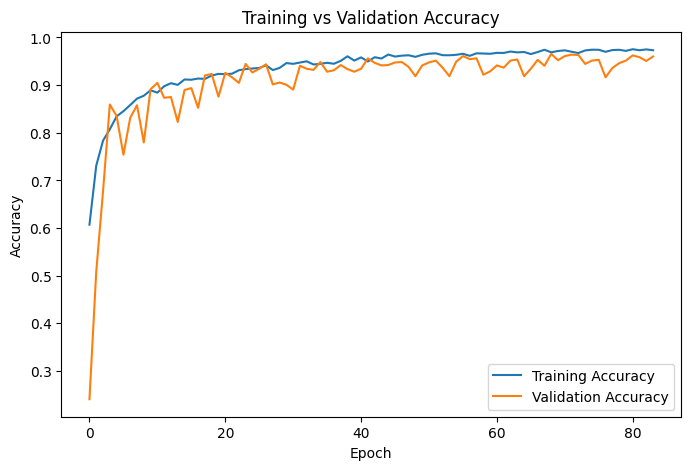

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [30]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.98      0.98      0.98       400
           2       0.98      0.93      0.95       400
           3       0.94      0.97      0.95       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600

